# Lista 5
### Maria Nowacka 275981

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np, matplotlib.pyplot as plt, optuna, warnings
from scipy.stats import expon, reciprocal
import time
from sklearn.datasets import load_breast_cancer
import xgboost as xgb
import lightgbm as lgb

### zadanie 1
Wprowadzenie do SVM: Zaimplementuj SVM od podstaw dla danych, które są liniowo separowalne. Skup się na znalezieniu optymalnej
hiperpłaszczyzny, która maksymalizuje margines między klasami.

iter 1500 | obj 3340.177 | ||w|| 81.733 | hinge sum 0.000
iter 3000 | obj 166.048 | ||w|| 18.224 | hinge sum 0.000
iter 4500 | obj 8.255 | ||w|| 4.063 | hinge sum 0.000
iter 6000 | obj 2.844 | ||w|| 2.385 | hinge sum 0.000

Wyniki końcowe:
w = [1.9391 1.3882]  b = 0.0
||w|| = 2.384752508425732
Liczba SV aprox: 0 | liczba violators: 0
Train acc: 1.0 Test acc: 0.96875


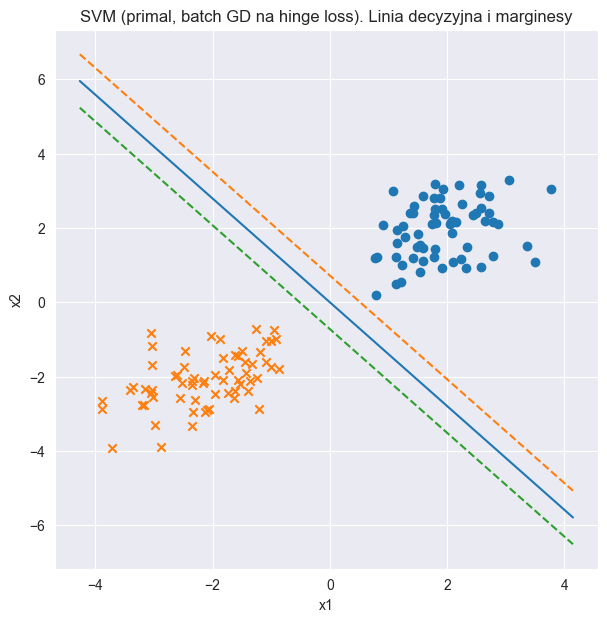

In [2]:
# - rozwiązujemy problem primalny SVM poprzez gradien descent na funkcji celu:
#     1/2 ||w||^2 + C * sum_i max(0, 1 - y_i (w·x_i + b))
#   (dla dużego C otrzymujemy przybliżenie hard-margin)

n_per_class = 80
mean1 = np.array([2.0, 2.0])
mean2 = np.array([-2.0, -2.0])
cov = np.array([[0.6, 0.2],[0.2, 0.6]])

X_pos = np.random.multivariate_normal(mean1, cov, size=n_per_class)
X_neg = np.random.multivariate_normal(mean2, cov, size=n_per_class)

X = np.vstack([X_pos, X_neg])
y = np.hstack([np.ones(n_per_class), -np.ones(n_per_class)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)

d = X_train.shape[1]
w = np.zeros(d)
b = 0.0

C = 1e3
lr = 0.001     # krok optymalizacji
n_iters = 6000

# batch gradient descent na celu: 0.5||w||^2 + C * sum hinge
for it in range(n_iters):
    margins = y_train * (X_train.dot(w) + b)  # y*(w·x + b)
    indicator = (margins < 1).astype(float)
    grad_w = w - C * np.dot(indicator * y_train, X_train)
    grad_b = - C * np.sum(indicator * y_train)
    # update
    w -= lr * grad_w
    b -= lr * grad_b

    if (it+1) % 1500 == 0:
        loss_hinge = np.maximum(0, 1 - margins).sum()
        obj = 0.5 * np.dot(w, w) + C * loss_hinge
        # print co jakiś czas
        print(f"iter {it+1:4d} | obj {obj:.3f} | ||w|| {np.linalg.norm(w):.3f} | hinge sum {loss_hinge:.3f}")

margins_all = y_train * (X_train.dot(w) + b)
support_idx = np.where(np.abs(margins_all - 1) <= 0.2)[0]   # tolerancja 0.2
violating_idx = np.where(margins_all < 1)[0]

train_acc = np.mean(np.sign(X_train.dot(w) + b) == y_train)
test_acc = np.mean(np.sign(X_test.dot(w) + b) == y_test)

print("\nWyniki końcowe:")
print("w =", np.round(w, 4), " b =", round(b,4))
print("||w|| =", np.linalg.norm(w))
print("Liczba SV aprox:", len(support_idx), "| liczba violators:", len(violating_idx))
print("Train acc:", train_acc, "Test acc:", test_acc)

plt.figure(figsize=(7,7))
plt.scatter(X_train[y_train==1,0], X_train[y_train==1,1])
plt.scatter(X_train[y_train==-1,0], X_train[y_train==-1,1], marker='x')

xmin, xmax = plt.xlim()
xs = np.linspace(xmin, xmax, 200)
if abs(w[1]) > 1e-8:
    ys = -(w[0]*xs + b) / w[1]
    ys_up = -(w[0]*xs + b - 1) / w[1]   # w·x + b = 1
    ys_down = -(w[0]*xs + b + 1) / w[1] # w·x + b = -1
    plt.plot(xs, ys)
    plt.plot(xs, ys_up, linestyle='--')
    plt.plot(xs, ys_down, linestyle='--')
else:
    x_line = -b / w[0]
    plt.axvline(x_line)
    plt.axvline(x_line + 1/w[0], linestyle='--')
    plt.axvline(x_line - 1/w[0], linestyle='--')

plt.scatter(X_train[support_idx,0], X_train[support_idx,1], s=150, facecolors='none', linewidths=1.5)

plt.title("SVM (primal, batch GD na hinge loss). Linia decyzyjna i marginesy")
plt.xlabel("x1"); plt.ylabel("x2")
plt.grid(True)
plt.show()


### zadanie 2
Zastosowanie SVM z `scikit-learn`: Wczytaj zbiór danych `Breast
Cancer` z biblioteki `scikit-learn`. Podziel dane na zbiór treningowy i
testowy. Zbuduj model SVM z jądrem liniowym (`kernel=’linear’`) i
oceń jego wydajność.

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred = svm_linear.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(accuracy, '\n', report)


0.9298245614035088 
               precision    recall  f1-score   support

           0       0.89      0.93      0.91        42
           1       0.96      0.93      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



### zadanie 3
Jądro (kernel trick): Wygeneruj syntetyczny zbiór danych, który nie
jest liniowo separowalny (np. dane w kształcie okręgów). Wytrenuj model SVM z jądrem Gaussa (`kernel=’rbf’`) i zwizualizuj granice decyzyjne. Porównaj wyniki z modelem SVM z jądrem liniowym i wyjaśnij,
dlaczego jądro RBF jest w tym przypadku skuteczniejsze.

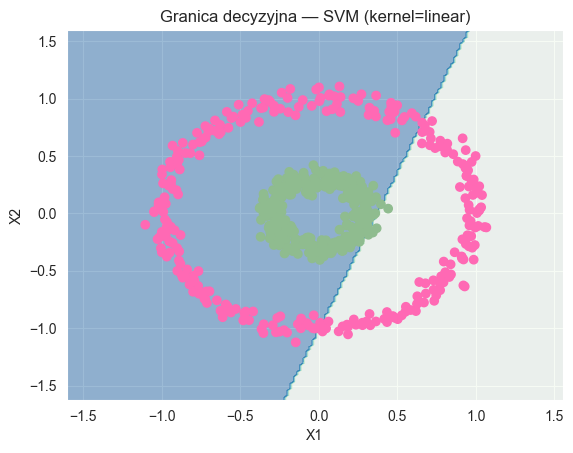

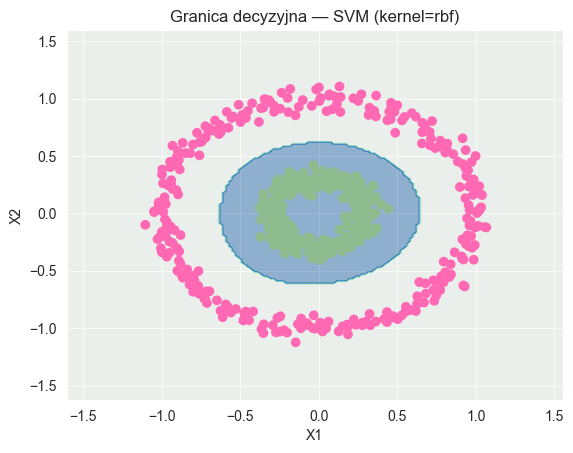

In [4]:
from sklearn.datasets import make_circles
from sklearn.svm import SVC
X, y = make_circles(n_samples=600, factor=0.3, noise=0.05)

svm_linear = SVC(kernel="linear")
svm_linear.fit(X, y)

svm_rbf = SVC(kernel="rbf")
svm_rbf.fit(X, y)

def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='GnBu')
    colors = ['hotpink' if label == 0 else 'darkseagreen' for label in y]
    plt.scatter(X[:, 0], X[:, 1], color=colors)
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

plot_decision_boundary(svm_linear, X, y, "Granica decyzyjna — SVM (kernel=linear)")

plot_decision_boundary(svm_rbf, X, y, "Granica decyzyjna — SVM (kernel=rbf)")


### zadanie 4
Dostrajanie hiperparametrów SVM: Dla modelu SVM na danych `Breast Cancer`, użyj `GridSearchCV` lub `RandomizedSearchCV` do
optymalizacji hiperparametrów, takich jak parametr regularyzacji C i
gamma ($\gamma$) dla jądra RBF. Porównaj wyniki z modelem o domyślnych
parametrach.

In [5]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

svm_default = SVC(kernel='rbf')
svm_default.fit(X_train, y_train)
y_pred_default = svm_default.predict(X_test)

print("--------- Wyniki modelu SVM (domyślne parametry) -------")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))

--------- Wyniki modelu SVM (domyślne parametry) -------
Accuracy: 0.8771929824561403
              precision    recall  f1-score   support

           0       0.97      0.69      0.81        42
           1       0.85      0.99      0.91        72

    accuracy                           0.88       114
   macro avg       0.91      0.84      0.86       114
weighted avg       0.89      0.88      0.87       114



In [16]:
param_grid = {
    'C': [0.1, 1, 10, 30, 40, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001, 0.0001]
}

grid = GridSearchCV(
    estimator=SVC(kernel='rbf'),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_grid = grid.best_estimator_
y_pred_grid = best_grid.predict(X_test)

print("Najlepsze parametry GridSearchCV: ", grid.best_params_)

print("--------- Wyniki SVM po GridSearchCV --------- ")
print("Accuracy:", accuracy_score(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid))



Najlepsze parametry GridSearchCV:  {'C': 40, 'gamma': 0.0001}
--------- Wyniki SVM po GridSearchCV --------- 
Accuracy: 0.9415204678362573
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        64
           1       0.95      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



In [20]:
param_distributions = {
    "C": reciprocal(0.1, 100),
    "gamma": reciprocal(0.0001, 1)
}

random_search = RandomizedSearchCV(
    estimator=SVC(kernel='rbf'),
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_random = random_search.best_estimator_
y_pred_random = best_random.predict(X_test)

print("Najlepsze parametry RandomizedSearchCV: ", random_search.best_params_)

print("--------- Wyniki SVM po RandomizedSearchCV -----------")
print("Accuracy:", accuracy_score(y_test, y_pred_random))
print(classification_report(y_test, y_pred_random))

Najlepsze parametry RandomizedSearchCV:  {'C': np.float64(59.71944262110629), 'gamma': np.float64(0.00011435177762120033)}
--------- Wyniki SVM po RandomizedSearchCV -----------
Accuracy: 0.9239766081871345
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        64
           1       0.94      0.93      0.94       107

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171



In [22]:
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.ERROR)
def objective(trial):
    C = trial.suggest_loguniform("C", 1e-3, 1e3)
    gamma = trial.suggest_loguniform("gamma", 1e-4, 1e1)

    model = SVC(kernel="rbf", C=C, gamma=gamma)
    score = cross_val_score(model, X, y, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

print("Najlepsze parametry przy uzyciu optuna: ",study.best_params)
best_model = SVC(
    C=study.best_params["C"],
    gamma=study.best_params["gamma"])
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("--------- Wyniki SVM przy użyciu optuna -----------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Najlepsze parametry przy uzyciu optuna:  {'C': 32.68593799888149, 'gamma': 0.00015122050068369937}
--------- Wyniki SVM przy użyciu optuna -----------
Accuracy: 0.9122807017543859
              precision    recall  f1-score   support

           0       0.88      0.89      0.88        64
           1       0.93      0.93      0.93       107

    accuracy                           0.91       171
   macro avg       0.91      0.91      0.91       171
weighted avg       0.91      0.91      0.91       171



### zadanie 5
Porównanie XGBoost i LightGBM: Zainstaluj i użyj bibliotek
`xgboost` i `lightgbm`. Wytrenuj oba modele na danych `Breast Cancer`
i porównaj ich czas treningu oraz dokładność. Zidentyfikuj, który z nich
jest szybszy i dlaczego.

In [23]:
warnings.filterwarnings("ignore")
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

n_runs = 10
xgb_times, xgb_accs = [], []
lgb_times, lgb_accs = [], []

for i in range(n_runs):
    # XGBoost
    # use_label_encoder=False, eval_metric='logloss',
    xgb_model = xgb.XGBClassifier(n_jobs=-1)
    start_time = time.time()
    xgb_model.fit(X_train, y_train)
    xgb_times.append(time.time() - start_time)
    xgb_accs.append(accuracy_score(y_test, xgb_model.predict(X_test)))

    # LightGBM
    lgb_model = lgb.LGBMClassifier(n_jobs=-1)
    start_time = time.time()
    lgb_model.fit(X_train, y_train)
    lgb_times.append(time.time() - start_time)
    lgb_accs.append(accuracy_score(y_test, lgb_model.predict(X_test)))

print("----- XGBoost ------")
print(f"Średni czas treningu: {np.mean(xgb_times):.4f} s ± {np.std(xgb_times):.4f}")
print(f"Średnia accuracy: {np.mean(xgb_accs):.4f} ± {np.std(xgb_accs):.4f}")

print("------ LightGBM ------")
print(f"Średni czas treningu: {np.mean(lgb_times):.4f} s ± {np.std(lgb_times):.4f}")
print(f"Średnia accuracy: {np.mean(lgb_accs):.4f} ± {np.std(lgb_accs):.4f}")


[LightGBM] [Info] Number of positive: 250, number of negative: 148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3972
[LightGBM] [Info] Number of data points in the train set: 398, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628141 -> initscore=0.524249
[LightGBM] [Info] Start training from score 0.524249
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

### zadanie 6
Walidacja krzyżowa (Cross-validation): Dla wybranego modelu
(np. XGBoost) przeprowadź walidację krzyżową (`KFold` lub
`StratifiedKFold`) w celu uzyskania bardziej rzetelnej oceny jego wydajności. Omów, dlaczego walidacja krzyżowa jest lepsza niż jednorazowy podział na zbiór treningowy i testowy.

In [10]:
X, y = load_breast_cancer(return_X_y=True)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True)

scores_kf = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

skf = StratifiedKFold(n_splits=5, shuffle=True)

scores_skf = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

print("-------------- KFold -------------- ")
print("Accuracy foldów:", scores_kf)
print(f"Średnia accuracy: {scores_kf.mean():.4f}")
print(f"Odchylenie std:   {scores_kf.std():.4f}")

print("--------- StratifiedKFold --------- ")
print("Accuracy foldów:", scores_skf)
print(f"Średnia accuracy: {scores_skf.mean():.4f}")
print(f"Odchylenie std:   {scores_skf.std():.4f}")

-------------- KFold -------------- 
Accuracy foldów: [0.98245614 0.97368421 0.97368421 0.96491228 0.95575221]
Średnia accuracy: 0.9701
Odchylenie std:   0.0091
--------- StratifiedKFold --------- 
Accuracy foldów: [0.99122807 0.94736842 0.97368421 0.94736842 0.96460177]
Średnia accuracy: 0.9649
Odchylenie std:   0.0166
